Dataset: https://data.mendeley.com/datasets/mthv4ppwyw/2

In [187]:
import os
import glob
import numpy as np
import cv2  
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter  
from tqdm import tqdm
import random
from pathlib import Path
import pandas as pd
import shutil

import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid") 
sns.set_palette("husl")

# CORN dataset

In [188]:
DATASET_ROOT = Path("Weed-crop RGB dataset")
DATASET_CORN = Path("Weed-crop RGB dataset/Corn")

In [189]:
def load_classes(dataset_root):
    """Load class names from classes.txt"""
    classes_file = dataset_root / "classes.txt"
    
    if not classes_file.exists():
        # Try to find it in subdirectories
        for crop_folder in dataset_root.iterdir():
            if crop_folder.is_dir():
                alt_classes = crop_folder / "classes.txt"
                if alt_classes.exists():
                    classes_file = alt_classes
                    break
    
    if classes_file.exists():
        with open(classes_file, 'r') as f:
            classes = [line.strip() for line in f.readlines()]
        return classes
    else:
        print("⚠️ classes.txt not found. Using default class order.")
        return None

# Load classes
class_names = load_classes(DATASET_ROOT)

We picked only one crop (Corn), which we will further use to our analysis, augmentation and to train and test our models.

### CORN dataset statisctics

In [190]:
def parse_yolo_annotation(label_path):
    
    annotations = []
    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    annotations.append({ 'class_id': class_id, 'x_center': x_center, 
                                         'y_center': y_center, 'width': width, 
                                         'height': height, 'area': width * height })
    except Exception as e:
        print(f"Error parsing {label_path}: {e}")
    return annotations

def load_annotations_from_folder(folder_path: Path):
    """
    Loads all annotations from a specific crop folder.
    """
    all_annotations = []
    class_counts = Counter()
    label_files = list(folder_path.rglob('*.txt'))


    print(f"Found {len(label_files)} .txt files")

    for label_file in tqdm(label_files, desc=f"Parsing {folder_path.name}"):
        
        if label_file.name == 'classes.txt':
            continue

        annotations = parse_yolo_annotation(label_file)

        for ann in annotations:
            ann['image_name'] = label_file.stem 
            all_annotations.append(ann)
            class_counts[ann['class_id']] += 1
            
    return all_annotations, class_counts

all_annotations, class_counts = load_annotations_from_folder(DATASET_CORN)

print(f"\n All instances: {len(all_annotations)}")
print(f" Unique classes: {len(class_counts)}")

Found 141 .txt files


Parsing Corn: 100%|██████████| 141/141 [00:00<00:00, 17904.84it/s]


 All instances: 1894
 Unique classes: 7


In [191]:
def load_class_names(file_path):
    with open(file_path, 'r') as f:
        class_names = {i: line.strip() for i, line in enumerate(f)}
    return class_names

CORN_CLASSES_FILE = DATASET_CORN / "classes.txt"
CLASS_NAMES = load_class_names(CORN_CLASSES_FILE)

results_list = []

for class_id, name in sorted(CLASS_NAMES.items()):

    count = class_counts.get(class_id, 0)
    if count > 0:
        results_list.append({
            'ID': class_id,
            'Class Name': name,
            'Instances': count
        })
    
df_results = pd.DataFrame(results_list)
display(df_results.style.hide(axis="index"))

ID,Class Name,Instances
2,Corn,1476
3,Field Pea,7
5,Horseweed,46
6,Kochia,76
8,Ragweed,102
9,Redroot Pigweed,99
12,Waterhemp,88


# Augmentation on CORN dataset

Augmentation folder and rules

In [192]:
AUG_DIR = Path("Weed-crop RGB dataset/Corn_augmented")
os.makedirs(AUG_DIR, exist_ok=True)
print(f"Stworzono folder wyjściowy: {AUG_DIR}")

TARGET_CLASS_ID = 2  # Corn class id
WEED_CLASS_IDS = [5, 6, 8, 9, 12] # Wedd classes ids

# Picture percentage
EDGE_THRESHOLD = 0.1  # How close to the edge should be the crop
WEED_DISTANCE_THRESHOLD = 0.1 # How far away the weed should be from teh crop so that it isn't its neighbor

MIN_BOX_AREA_PERCENTAGE = 0.15 # Minimal crop bounding box area that makes crop valuable
# After image cut, if the value is less than MIN_BOX_AREA_PERCENTAGE, the algorithm will not put the object into label file
# If the value is larger than this treshold, the algorithm willadjust label for this bounding box

global_class_counts = class_counts.copy() # Instance counter to monitor the number of instances throughout the augmentation

TARGET_INSTANCE_COUNT = 500 # To what number should we reduce Corn class instances

Stworzono folder wyjściowy: Weed-crop RGB dataset/Corn_augmented


Helper functions

In [193]:
def get_image_path(label_path: Path):
    """
    Finds the corresponding image file for a given YOLO label file path.
    """
    extensions = ['.JPG', '.jpg', '.PNG', '.png', '.jpeg', '.JPEG']
    for ext in extensions:
        img_path = label_path.with_suffix(ext)
        if img_path.exists():
            return img_path
    return None 

def save_yolo_labels(labels_list_of_dicts, save_path: Path):
    """
    Saves a list of label dictionaries to a file in the standard 
    YOLO .txt format.
    """
   
    with open(save_path, 'w') as f:
        for label in labels_list_of_dicts:
            line = f"{label['class_id']} {label['x_center']} {label['y_center']} {label['width']} {label['height']}\n"
            f.write(line)

def convert_yolo_to_pixels(labels, img_w, img_h):
    """
    Converts a list of labels from normalized YOLO format (0-1) to 
    absolute pixel coordinates.
    """
    pixel_labels = []
    for ann in labels:
        x_c = ann['x_center']
        y_c = ann['y_center']
        w = ann['width']
        h = ann['height']
        
        xmin = int((x_c - w / 2) * img_w)
        xmax = int((x_c + w / 2) * img_w)
        ymin = int((y_c - h / 2) * img_h)
        ymax = int((y_c + h / 2) * img_h)
        
        pixel_labels.append({
            'class_id': ann['class_id'],
            'px_xmin': xmin, 'px_ymin': ymin,
            'px_xmax': xmax, 'px_ymax': ymax
        })
    return pixel_labels

def convert_pixels_to_yolo(pixel_labels, img_w, img_h):
    """
    Converts a list of labels from absolute pixel coordinates 
    back to normalized YOLO format (0-1).
    """
    yolo_labels = []
    for ann in pixel_labels:
        px_w = ann['px_xmax'] - ann['px_xmin']
        px_h = ann['px_ymax'] - ann['px_ymin']
       
        px_x_c = ann['px_xmin'] + px_w / 2
        px_y_c = ann['px_ymin'] + px_h / 2
        
        x_center = px_x_c / img_w
        y_center = px_y_c / img_h
        width = px_w / img_w
        height = px_h / img_h
        
        yolo_labels.append({
            'class_id': ann['class_id'],
            'x_center': x_center, 'y_center': y_center,
            'width': width, 'height': height
        })
    return yolo_labels

In [194]:

def is_near_edge(box, edge_threshold):
    """
    Checks if a bounding box is close to any of the four image edges.
    """
    x_min = box['x_center'] - box['width'] / 2
    x_max = box['x_center'] + box['width'] / 2
    y_min = box['y_center'] - box['height'] / 2
    y_max = box['y_center'] + box['height'] / 2
    return (x_min < edge_threshold or x_max > (1 - edge_threshold) or
            y_min < edge_threshold or y_max > (1 - edge_threshold))

def get_box_distance(box1, box2):
    """
    Calculates the Chebyshev distance (max of x/y distances) between the 
    centers of two bounding boxes.
    """
    dist_x = abs(box1['x_center'] - box2['x_center'])
    dist_y = abs(box1['y_center'] - box2['y_center'])
    return max(dist_x, dist_y)

def is_cut_safe(all_weeds, side, crop_box, labels, original_w, original_h):
    """
    Checks if a proposed augmentation cut is "safe" for all weeds.
    A cut is defined as "safe" if it does not remove or clip any 
    part (not even a single pixel) of any weed bounding box.
    """

    if not all_weeds:
        return True 

    pixel_labels = convert_yolo_to_pixels(labels, original_w, original_h)
    all_corn_boxes_px = [b for b in pixel_labels if b['class_id'] == TARGET_CLASS_ID]
    
    keep_x_min, keep_y_min = 0, 0
    keep_x_max, keep_y_max = original_w, original_h

    if side == "left":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_xmin'] / original_w) < EDGE_THRESHOLD]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_xmin'], reverse=True)
                keep_x_min = edge_corns[0]['px_xmin'] 
            else:
                keep_x_min = max(b['px_xmax'] for b in edge_corns)
                
    elif side == "right":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_xmax'] / original_w) > (1 - EDGE_THRESHOLD)]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_xmax'])
                keep_x_max = edge_corns[0]['px_xmax']
            else:
                keep_x_max = min(b['px_xmin'] for b in edge_corns)

    elif side == "top":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_ymin'] / original_h) < EDGE_THRESHOLD]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_ymin'], reverse=True)
                keep_y_min = edge_corns[0]['px_ymin']
            else:
                keep_y_min = max(b['px_ymax'] for b in edge_corns)
            
    elif side == "bottom":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_ymax'] / original_h) > (1 - EDGE_THRESHOLD)]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_ymax'])
                keep_y_max = edge_corns[0]['px_ymax']
            else:
                keep_y_max = min(b['px_ymin'] for b in edge_corns)

    all_weeds_px = convert_yolo_to_pixels(all_weeds, original_w, original_h)
    
    for weed_box in all_weeds_px:
        orig_w = weed_box['px_xmax'] - weed_box['px_xmin']
        orig_h = weed_box['px_ymax'] - weed_box['px_ymin']
        if orig_w == 0 or orig_h == 0: continue
        orig_area = orig_w * orig_h

        new_xmin = max(keep_x_min, weed_box['px_xmin'])
        new_ymin = max(keep_y_min, weed_box['px_ymin'])
        new_xmax = min(keep_x_max, weed_box['px_xmax'])
        new_ymax = min(keep_y_max, weed_box['px_ymax'])

        new_w = new_xmax - new_xmin
        new_h = new_ymax - new_ymin
        
        if new_w <= 0 or new_h <= 0:
            return False 
        
        new_area = new_w * new_h
        
        if new_area < orig_area:
            return False 

    return True 

def get_min_distance_to_weeds(corn_box, all_weeds):
    """
    Calculates the distance from a single 'corn' box to the nearest weed.
    """
    if not all_weeds:
        return float('inf')
    
    min_dist = float('inf')
    for weed in all_weeds:
        dist = get_box_distance(corn_box, weed)
        if dist < min_dist:
            min_dist = dist
    return min_dist

def find_candidate_to_crop(labels, target_id, weed_ids, edge_thresh, dist_thresh, original_w, original_h):
    """
    This function implements the core logic:
    1. Finds all 'corn' boxes.
    2. Filters out any 'corn' box that is too close to a weed.
    3. Filters out any 'corn' box that is not near an edge.
    4. For all remaining candidates, it runs the ultimate `is_cut_safe` 
       check to ensure no weeds will be harmed.
    5. It then selects the one candidate that is farthest from any weed,
       as this is the "least valuable" box.
    """
    weeds = [box for box in labels if box['class_id'] in weed_ids]
    corns = [box for box in labels if box['class_id'] == target_id]
    
    if not corns:
        return None, None

    safe_candidates = [] 

    for corn_box in corns:
        if not is_near_edge(corn_box, edge_thresh):
            continue 

        is_too_close_to_weed = False
        if weeds:
            for weed_box in weeds:
                if get_box_distance(corn_box, weed_box) < dist_thresh:
                    is_too_close_to_weed = True
                    break 
        if is_too_close_to_weed:
            continue 

        x_min = corn_box['x_center'] - corn_box['width'] / 2
        x_max = corn_box['x_center'] + corn_box['width'] / 2
        y_min = corn_box['y_center'] - corn_box['height'] / 2
        y_max = corn_box['y_center'] + corn_box['height'] / 2
        
        side = None
        if x_min < edge_thresh: side = "left"
        elif x_max > (1 - edge_thresh): side = "right"
        elif y_min < edge_thresh: side = "top"
        elif y_max > (1 - edge_thresh): side = "bottom"
        else: continue

        if is_cut_safe(weeds, side, corn_box, labels, original_w, original_h):
            min_dist_to_weed = get_min_distance_to_weeds(corn_box, weeds)
            safe_candidates.append( (corn_box, side, min_dist_to_weed) )
    
    if not safe_candidates:
        return None, None
        
    safe_candidates.sort(key=lambda x: x[2], reverse=True)
    
    best_candidate = safe_candidates[0]
    
    return best_candidate[0], best_candidate[1]

In [195]:
def apply_crop_and_pad(image, labels, crop_box, side, original_h, original_w):
    """
    Executes the cut decision from 'find_candidate_to_crop'.

    This function creates the new augmented image by:
    1.  Calculating a cut line that removes the entire
        target row, not just the single trigger box.
    2.  Applying a safety check to prevent creating
        images with no Corn objects left.
    3.  Removing any tiny sliver boxes (less than x% of their
        original size) that result from the cut.
    4.  Placing the final cropped image onto a black padded background
        to maintain the original image size.
    5.  Recalculating all remaining labels to fit the new image.
    """
    
    final_image = np.zeros_like(image)
    pixel_labels = convert_yolo_to_pixels(labels, original_w, original_h)
    
    all_corn_boxes_px = [b for b in pixel_labels if b['class_id'] == TARGET_CLASS_ID]
    
    keep_x_min, keep_y_min = 0, 0
    keep_x_max, keep_y_max = original_w, original_h

    if side == "left":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_xmin'] / original_w) < EDGE_THRESHOLD]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_xmin'], reverse=True) 
                keep_x_min = edge_corns[0]['px_xmin'] 
            else:
                keep_x_min = max(b['px_xmax'] for b in edge_corns)
                
    elif side == "right":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_xmax'] / original_w) > (1 - EDGE_THRESHOLD)]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_xmax']) 
                keep_x_max = edge_corns[0]['px_xmax']
            else:
                keep_x_max = min(b['px_xmin'] for b in edge_corns)

    elif side == "top":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_ymin'] / original_h) < EDGE_THRESHOLD]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_ymin'], reverse=True) 
                keep_y_min = edge_corns[0]['px_ymin']
            else:
                keep_y_min = max(b['px_ymax'] for b in edge_corns)
            
    elif side == "bottom":
        edge_corns = [b for b in all_corn_boxes_px if (b['px_ymax'] / original_h) > (1 - EDGE_THRESHOLD)]
        if edge_corns:
            if len(edge_corns) > 0 and len(edge_corns) == len(all_corn_boxes_px):
                edge_corns.sort(key=lambda b: b['px_ymax']) 
                keep_y_max = edge_corns[0]['px_ymax']
            else:
                keep_y_max = min(b['px_ymin'] for b in edge_corns)

    keep_x_min = min(max(0, keep_x_min), original_w)
    keep_x_max = min(max(0, keep_x_max), original_w)
    keep_y_min = min(max(0, keep_y_min), original_h)
    keep_y_max = min(max(0, keep_y_max), original_h)
    
    if keep_x_min >= keep_x_max or keep_y_min >= keep_y_max:
        return image, labels 
        
    final_image[keep_y_min:keep_y_max, keep_x_min:keep_x_max] = \
        image[keep_y_min:keep_y_max, keep_x_min:keep_x_max]
    
    new_pixel_labels = []
    for box in pixel_labels:
        
        orig_w = box['px_xmax'] - box['px_xmin']
        orig_h = box['px_ymax'] - box['px_ymin']
        if orig_w <= 0 or orig_h <= 0: continue
        orig_area = orig_w * orig_h

        new_px_xmin = max(keep_x_min, box['px_xmin'])
        new_px_ymin = max(keep_y_min, box['px_ymin'])
        new_px_xmax = min(keep_x_max, box['px_xmax'])
        new_px_ymax = min(keep_y_max, box['px_ymax'])

        new_w = new_px_xmax - new_px_xmin
        new_h = new_px_ymax - new_px_ymin
        
        if new_w <= 0 or new_h <= 0:
            continue

        new_area = new_w * new_h
        remaining_percentage = new_area / orig_area
        
        if box['class_id'] == TARGET_CLASS_ID:
            if remaining_percentage >= MIN_BOX_AREA_PERCENTAGE:
                new_pixel_labels.append({
                    'class_id': box['class_id'], 'px_xmin': new_px_xmin, 
                    'px_ymin': new_px_ymin, 'px_xmax': new_px_xmax, 'px_ymax': new_px_ymax
                })
        else:
            new_pixel_labels.append({
                'class_id': box['class_id'], 'px_xmin': new_px_xmin, 
                'px_ymin': new_px_ymin, 'px_xmax': new_px_xmax, 'px_ymax': new_px_ymax
            })

    final_yolo_labels = convert_pixels_to_yolo(new_pixel_labels, original_w, original_h)
    
    has_corn = any(b['class_id'] == TARGET_CLASS_ID for b in final_yolo_labels)
    if not has_corn and len(all_corn_boxes_px) > 0:
        return image, labels
        
    return final_image, final_yolo_labels

In [ ]:
print("--- Starting Augmentation (Iterative Undersampling) ---")
print(f"Source folder: {DATASET_CORN}")
print(f"Target folder: {AUG_DIR}")

augmented_example_paths = []

label_files = list(DATASET_CORN.glob('*.txt'))
label_files = [f for f in label_files if f.name != 'classes.txt']
print(f"Found {len(label_files)} label files to process.")

shutil.copy(DATASET_CORN / "classes.txt", AUG_DIR / "classes.txt")

for label_path in tqdm(label_files, desc="Processing images"):
    
    image_path = get_image_path(label_path)
    if not image_path:
        print(f"Warning: Could not find matching image for label {label_path.name}")
        continue
        
    base_name = label_path.stem 
    output_label_path = AUG_DIR / (base_name + ".txt")
    output_image_path = AUG_DIR / (base_name + ".jpg")

    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Error: Failed to load image {image_path}")
        continue
    original_h, original_w, _ = image.shape
    
    original_labels = parse_yolo_annotation(label_path) 

    if global_class_counts[TARGET_CLASS_ID] <= TARGET_INSTANCE_COUNT:
        shutil.copy(image_path, output_image_path)
        shutil.copy(label_path, output_label_path)
        continue

    current_image = image.copy()
    current_labels = original_labels.copy()
    
    did_we_crop_this_image = False 
    
    while True:
        if global_class_counts[TARGET_CLASS_ID] <= TARGET_INSTANCE_COUNT:
            break
            
        candidate_box, side = find_candidate_to_crop(
            current_labels, TARGET_CLASS_ID, WEED_CLASS_IDS, 
            EDGE_THRESHOLD, WEED_DISTANCE_THRESHOLD,
            original_w, original_h  
        )
        
        if candidate_box:
            new_image, new_labels = apply_crop_and_pad(
                current_image, current_labels, candidate_box, side, original_h, original_w
            )
            
            old_corn_count = len([b for b in current_labels if b['class_id'] == TARGET_CLASS_ID])
            new_corn_count = len([b for b in new_labels if b['class_id'] == TARGET_CLASS_ID])

            current_image = new_image
            current_labels = new_labels
            did_we_crop_this_image = True 
            
            global_class_counts[TARGET_CLASS_ID] -= (old_corn_count - new_corn_count)
            
            if old_corn_count == new_corn_count:
                break
            
        else:
            break
            
    if did_we_crop_this_image:
        cv2.imwrite(str(output_image_path), current_image)
        save_yolo_labels(current_labels, output_label_path)
        
        if len(augmented_example_paths) < 10: 
            augmented_example_paths.append(
                (str(image_path), str(label_path), str(output_image_path), str(output_label_path))
            )
        
    else:
        shutil.copy(image_path, output_image_path)
        shutil.copy(label_path, output_label_path)

print('Augmentation finished')
print('\n Class distribution after augmentation')
results_list = []
for class_id, name in sorted(CLASS_NAMES.items()):

    count = global_class_counts.get(class_id, 0)
    
    if count > 0:
        results_list.append({
            'ID': class_id,
            'Class Name': name,
            'Instances': count
        })
    
df_results = pd.DataFrame(results_list)
display(df_results.style.hide(axis="index"))

--- Starting Augmentation (Iterative Undersampling) ---
Source folder: Weed-crop RGB dataset/Corn
Target folder: Weed-crop RGB dataset/Corn_augmented
Found 140 label files to process.


Processing images: 100%|██████████| 140/140 [00:32<00:00,  4.35it/s]

Augmentation finished

 Class distribution after augmentation


ID,Class Name,Instances
2,Corn,815
3,Field Pea,7
5,Horseweed,46
6,Kochia,76
8,Ragweed,102
9,Redroot Pigweed,99
12,Waterhemp,88


Displaying augmented examples


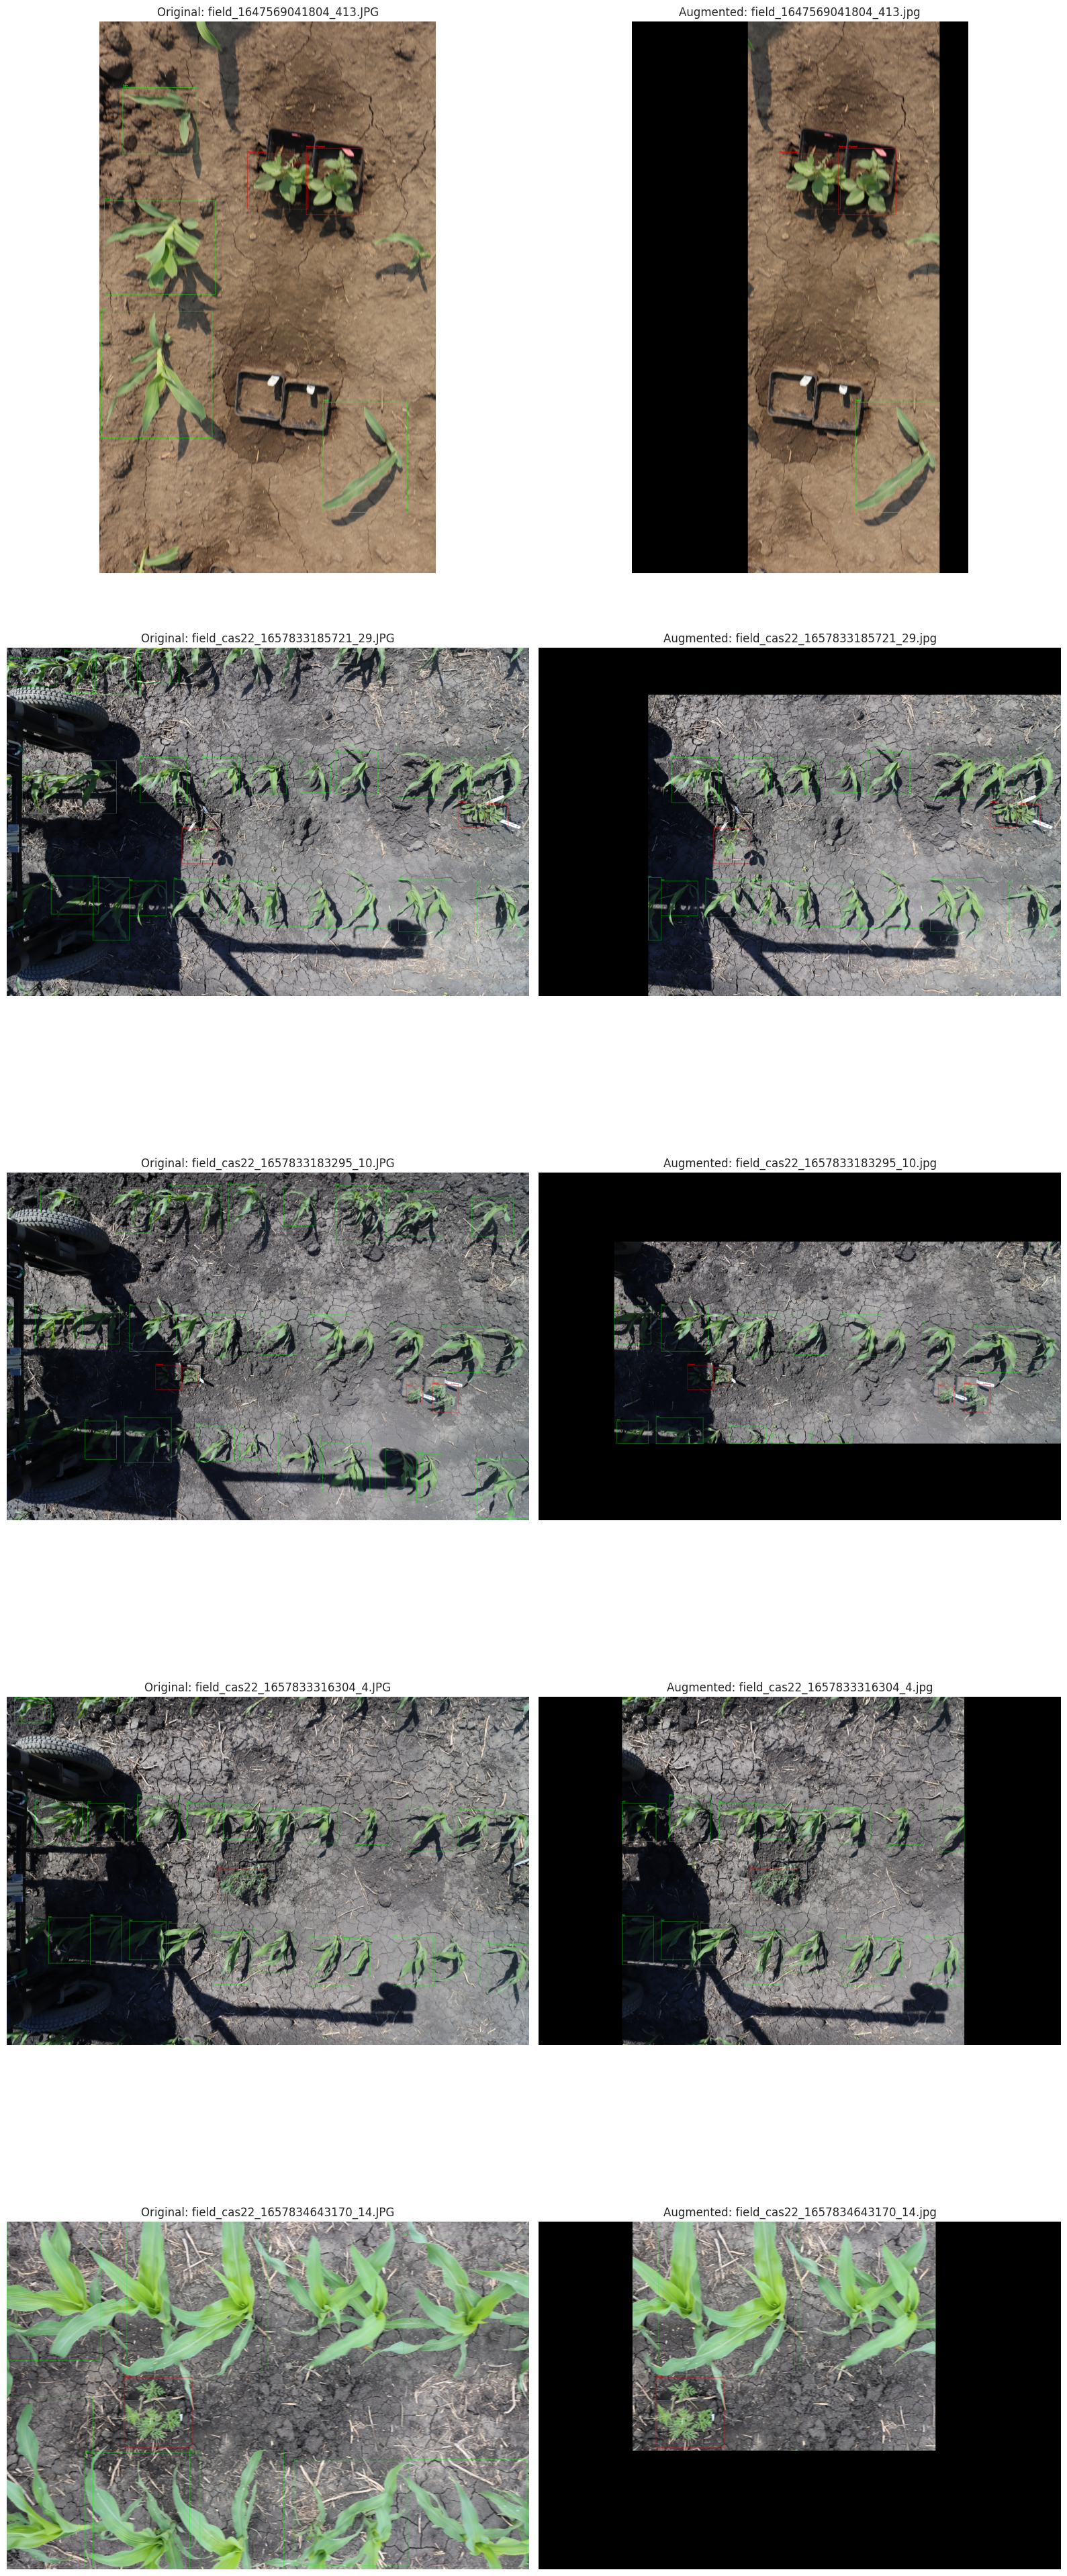

In [197]:
def draw_boxes_on_image(img_path: str, label_path: str):
    COLOR_MAP = {
        TARGET_CLASS_ID: (0, 255, 0) 
    }
    for weed_id in WEED_CLASS_IDS:
        COLOR_MAP[weed_id] = (0, 0, 255) 
    DEFAULT_COLOR = (255, 0, 0) 
    
    image = cv2.imread(img_path)
    if image is None:
        return np.zeros((480, 480, 3), dtype=np.uint8) 
        
    h, w, _ = image.shape
    labels = parse_yolo_annotation(label_path)
    
    for ann in labels:
        class_id = ann['class_id']
        name = CLASS_NAMES.get(class_id, "Unknown")
        color = COLOR_MAP.get(class_id, DEFAULT_COLOR)
        
        x_c, y_c = ann['x_center'], ann['y_center']
        w_norm, h_norm = ann['width'], ann['height']
        
        xmin = int((x_c - w_norm / 2) * w)
        xmax = int((x_c + w_norm / 2) * w)
        ymin = int((y_c - h_norm / 2) * h)
        ymax = int((y_c + h_norm / 2) * h)
 
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 2)

        cv2.putText(image, name, (xmin, ymin - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                    
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

if not augmented_example_paths:
    print("No images were augmented. Nothing to display.")
else:
    num_examples = len(augmented_example_paths)
    fig, axes = plt.subplots(num_examples, 2, figsize=(16, num_examples * 8))
    
    print("Displaying augmented examples")

    if num_examples == 1:
        axes = np.array([axes])
    
    for i, (orig_img_p, orig_lbl_p, aug_img_p, aug_lbl_p) in enumerate(augmented_example_paths):
        
        img_original_rgb = draw_boxes_on_image(orig_img_p, orig_lbl_p)
        img_augmented_rgb = draw_boxes_on_image(aug_img_p, aug_lbl_p)
        
        ax_orig = axes[i, 0]
        ax_orig.imshow(img_original_rgb)
        ax_orig.set_title(f"Original: {Path(orig_img_p).name}")
        ax_orig.axis('off')
        
        ax_aug = axes[i, 1]
        ax_aug.imshow(img_augmented_rgb)
        ax_aug.set_title(f"Augmented: {Path(aug_img_p).name}")
        ax_aug.axis('off')

    plt.tight_layout()
    plt.show()

### Algorithm pipeline

1. Objective    

    The primary goal of this algorithm is to perform intelligent undersampling on a class-imbalanced object detection dataset. It aims to reduce the instance count of a specified majority class (e.g., 'Corn', TARGET_CLASS_ID) while adhering to one critical constraint: no minority class instance (e.g., 'Weed', WEED_CLASS_IDS) may be removed or partially clipped.

    This is achieved by iteratively cropping "unimportant" majority-class instances from the image borders and replacing the cropped area with black padding, thus preserving image dimensions.    

2. The Main Pipeline (Iterative Loop)

    The algorithm processes the entire dataset image by image. For each image, it enters an iterative while loop that performs the following steps:
    * Analyze Image: The algorithm analyzes the current state of the image and its labels.
    * Find Best Target: It executes the find_candidate_to_crop function to find the single best 'Corn' instance to remove.   

    Check for Target:
    * If a safe target is found: The algorithm executes the apply_crop_and_pad function. This creates a new, cropped version of the image. This new image then becomes the input for the next iteration of the while loop (Step 1).
    * If no safe target is found: The while loop breaks.   

    Save Result: The final version of the image (either the augmented one or the original if no cuts were made) is saved to the Corn_augmented directory.

    This iterative process allows the algorithm to perform multiple cuts on a single image (e.g., removing an entire row, one piece at a time) until no "safe" cuts remain.

3. Core Logic: Candidate Selection 

    This section describes the find_candidate_to_crop function, which finds the single best target for removal.   

    Filtering: The function first identifies all 'Corn' instances and filters them based on two rules:
    * Edge Filter: It keeps only 'Corn' boxes that are near an image border (defined by EDGE_THRESHOLD).
    * Proximity Filter: It discards any 'Corn' box that is too close to a 'Weed' (defined by WEED_DISTANCE_THRESHOLD). This protects instances that are actively interacting with a weed.   

    Ultimate Safety Check (is_cut_safe): This is the most critical logic. For every 'Corn' candidate that passes the filters, the algorithm performs a full "safety simulation":
    * It simulates the exact cut line that apply_crop_and_pad would create.
    * It checks this line against every 'Weed' box on the entire image.
    * If the cut would clip or remove even a single pixel of any 'Weed', the candidate is deemed "unsafe" and is discarded.

    Final Selection (The "Best" Candidate):
    * After the safety check, the algorithm may have multiple "safe" candidates.
    * It calculates the distance from each safe candidate to its nearest weed.
    * It selects only the one candidate that is farthest from any weed. This is considered the "least valuable" instance on the image and is the only target selected for this iteration.

4. Core Logic: Cropping & Padding

    This section describes the apply_crop_and_pad function (V5.3), which executes the cut.

    Intelligent Cut: The function does not just cut at the trigger box's edge. It scans for all other 'Corn' boxes in the same row and sets the cut line at the "deepest" edge of the entire row. This ensures the whole group is removed cleanly, not one-by-one.

    "Protect Last Row" Logic: A critical safety check. If the algorithm detects that all 'Corn' instances on the image are in the target cut zone (e.g., all 'Corn' is in one row on the right), it modifies the cut line to preserve the single deepest row. This guarantees that at least one 'Corn' instance will always remain on the final image, preventing "weed-only" images.

    Padding: The resulting "safe" portion of the image is copied onto a new black canvas that matches the original_h and original_w.

    Label Recalculation & "Sliver" Removal:
    * All labels (both 'Corn' and 'Weed') are recalculated based on the new "safe" area.
    * Any 'Corn' box that has less than MIN_BOX_AREA_PERCENTAGE (25%) of its original area after the cut is considered a "sliver" and is deleted from the final label file, as it provides no training value.
    * 'Weed' labels are preserved, as they were already guaranteed to be 100% intact by the is_cut_safe function.

    Final Safety Check: As a final precaution, the function checks the resulting final_yolo_labels. If it accidentally created a "weed-only" image (0 'Corn' instances), it reverts the change and returns the original image and labels.